In [54]:
from matplotlib import pyplot as plt;
import numpy as np;

In [82]:

txt = [ 'All that we are is the result of what we have thought',
         'To be or not to be that is the question',
         'Be yourself everyone else is already taken' ];


In [83]:
sentance = ' '.join(txt).lower();

words = (sentance).split(" ")

print(words)

watchTable = sorted(set(words))
print(watchTable)


['all', 'that', 'we', 'are', 'is', 'the', 'result', 'of', 'what', 'we', 'have', 'thought', 'to', 'be', 'or', 'not', 'to', 'be', 'that', 'is', 'the', 'question', 'be', 'yourself', 'everyone', 'else', 'is', 'already', 'taken']
['all', 'already', 'are', 'be', 'else', 'everyone', 'have', 'is', 'not', 'of', 'or', 'question', 'result', 'taken', 'that', 'the', 'thought', 'to', 'we', 'what', 'yourself']


In [84]:
encoderCorpus = {};
for i, word in enumerate(watchTable):
    encoderCorpus[word] = i;
print(encoderCorpus);

decoderCorpus = {};
for i, word in enumerate(watchTable):
    decoderCorpus[i] = word;
print(decoderCorpus);

{'all': 0, 'already': 1, 'are': 2, 'be': 3, 'else': 4, 'everyone': 5, 'have': 6, 'is': 7, 'not': 8, 'of': 9, 'or': 10, 'question': 11, 'result': 12, 'taken': 13, 'that': 14, 'the': 15, 'thought': 16, 'to': 17, 'we': 18, 'what': 19, 'yourself': 20}
{0: 'all', 1: 'already', 2: 'are', 3: 'be', 4: 'else', 5: 'everyone', 6: 'have', 7: 'is', 8: 'not', 9: 'of', 10: 'or', 11: 'question', 12: 'result', 13: 'taken', 14: 'that', 15: 'the', 16: 'thought', 17: 'to', 18: 'we', 19: 'what', 20: 'yourself'}


In [39]:
def encoder(sentance: str) -> list[int]:
    w = sentance.split(" ");
    result = [encoderCorpus[i.lower()] for i in w];
    return result;

def decoder(tokens: list[int]) -> str:
    result = [decoderCorpus[i] for i in tokens];
    print(result);
    return ' '.join(result);

In [46]:
# for i in txt:
#     encodedTxt = encoder(i);
#     print(encodedTxt);

#     decodedtxt = decoder(encodedTxt);
#     print(decodedtxt)
encodedTxt = encoder(sentance);
print(encodedTxt)

[0, 14, 18, 2, 7, 15, 12, 9, 19, 18, 6, 16, 17, 3, 10, 8, 17, 3, 14, 7, 15, 11, 3, 20, 5, 4, 7, 1, 13]


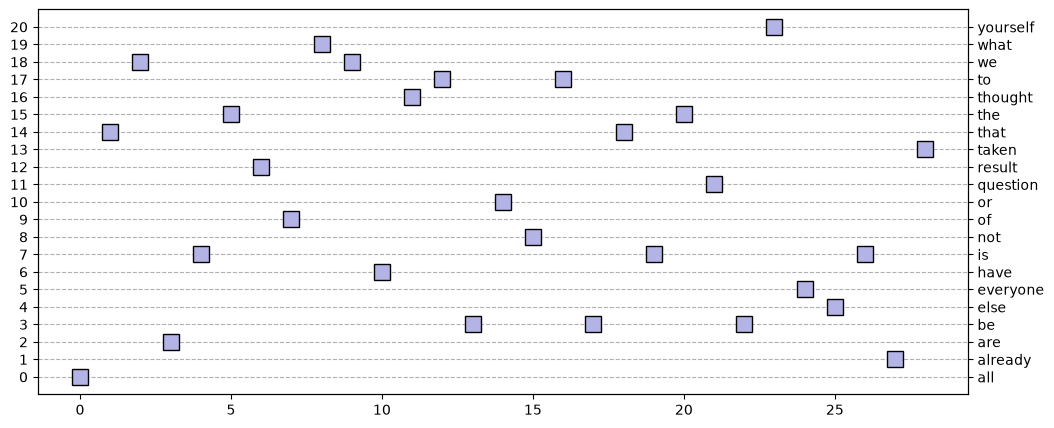

In [ ]:
_,ax = plt.subplots(1,figsize=(12,5));
ax.plot(encodedTxt,'ks',markersize=12,markerfacecolor=[.7,.7,.9]);
ax.set(yticks=range(len(watchTable)));
ax.grid(linestyle='--',axis='y');

ax2 = ax.twinx();
ax2.plot(encodedTxt,alpha=0);
ax2.set(yticks=range(len(watchTable)),yticklabels=watchTable);
plt.show();

In [81]:
findTo = np.where(np.array(words) == "to")[0];
print(f"all the instances of the word 'to' is {findTo}");

for i, ix in enumerate(findTo):
    print(f"context of the {i+1} instance is {" ".join(words[ix-1 : ix + 2])}")
    # print(f"context of the {i+1} instance is {" ".join(words[ix + 1])}")

all the instances of the word 'to' is [12 16]
context of the 1 instance is thought to be
context of the 2 instance is not to be


One-Hot encoding:


Implimentation:
    select a word from the txt sentance.
    find the index of that word from the vecob.
    create a np array with zeros at a len of vecob.
    change the value of the index from the word and vecob to 1.
    then append it into a array.
    the result 2d array will be the expected one-hot encoding.

In [111]:
oneHotEncode = np.zeros((len(words), len(encoderCorpus)));
# oneHotEncode = []

for i, w in enumerate(words):
    oneHotEncode[i][encoderCorpus[w]] = 1;
    # row = [0] * len(encoderCorpus);
    # row[encoderCorpus[w]] = 1;
    # oneHotEncode.append(row);

print(f"One-hot encoding matrix is od size ({len(oneHotEncode)}, {len(oneHotEncode[0])})")
print(oneHotEncode)


One-hot encoding matrix is od size (29, 21)
[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 

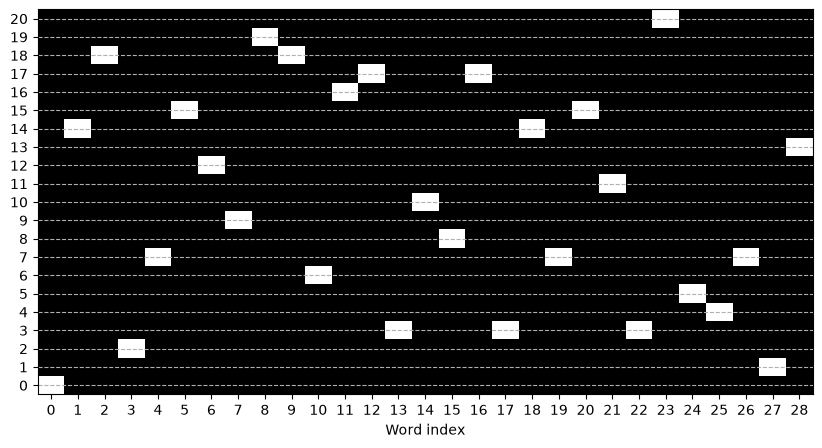

In [109]:
_,ax = plt.subplots(1,figsize=(10,5));
plt.imshow(oneHotEncode.T, cmap='grey', origin='lower', aspect='auto')
ax.set(xlabel='Word index', yticks=range(len(encoderCorpus)), xticks=range(len(words)));
ax.grid(linestyle='--', axis='y');
plt.show()